In [1]:
# importing libraries
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast 
import seaborn as sns 

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_list(lists):
    if pd.notna(lists):
        return ast.literal_eval(lists)
df['job_skills'] = df['job_skills'].apply(clean_list)

/opt/anaconda3/envs/python_da/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
df_DA_US['job_posted_month'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_explode = df_DA_US.explode('job_skills')

In [ ]:
df_DA_US_explode_pivot = df_DA_US_explode.pivot_table(index= 'job_posted_month', columns= 'job_skills', aggfunc='size', fill_value= 0)
df_DA_US_explode_pivot.loc['Total'] = df_DA_US_explode_pivot.sum()
df_DA_US_explode_pivot= df_DA_US_explode_pivot[df_DA_US_explode_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_US_explode_pivot= df_DA_US_explode_pivot.drop('Total')



In [40]:
DA_total = df_DA_US.groupby('job_posted_month').size()
df_DA_US_Percent = df_DA_US_explode_pivot.div(DA_total/100, axis= 0)

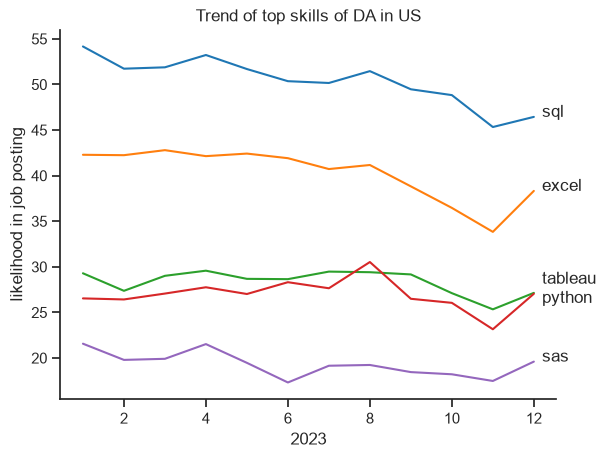

In [54]:
df_plot = df_DA_US_Percent.iloc[:,:5]
sns.lineplot(data= df_plot, dashes=False, palette='tab10')
sns.set_theme(style= 'ticks')
sns.despine()

plt.title('Trend of top skills of DA in US')
plt.xlabel('2023')
plt.ylabel('likelihood in job posting')
plt.legend().remove()


for i in range(5):
    y = df_plot.iloc[-1, i]
    
    if df_plot.columns[i] == 'tableau':
        y += 1
    elif df_plot.columns[i] == 'python':
        y -= 1
        
    plt.text(12.2, y, df_plot.columns[i])
